In [2]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import seaborn as sns

In [3]:
data_url = "https://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Process data: alternate rows contain features, and the target is in the second row, column 2
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]
df = pd.DataFrame(data, columns=feature_names)
df['PRICE'] = target

Feature names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Shape of data: (506, 13) (506,)
First 5 rows of data:
       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


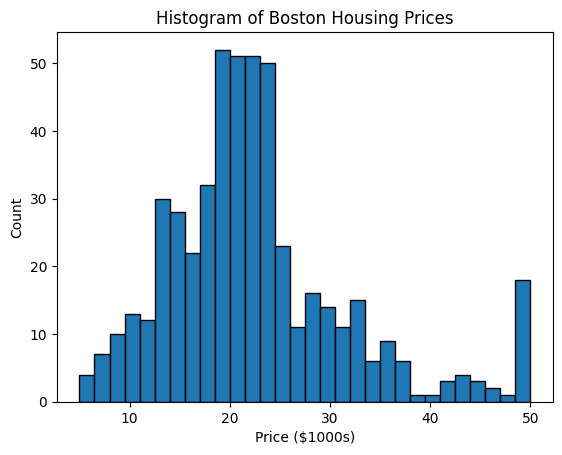

In [4]:
#Seperate X and y
X_boston = df.drop(columns='PRICE').values
y_boston = df['PRICE'].values

# Print info
print('Feature names:', feature_names)
print('Shape of data:', X_boston.shape, y_boston.shape)
print('First 5 rows of data:\n', df.head())

# Histogram of target prices
plt.hist(y_boston, bins=30, edgecolor='k')
plt.xlabel('Price ($1000s)')
plt.ylabel ('Count')
plt.title ('Histogram of Boston Housing Prices')
plt.savefig ("Boston_histogram.png" , dpi =300 , bbox_inches = 'tight')
plt.show ()

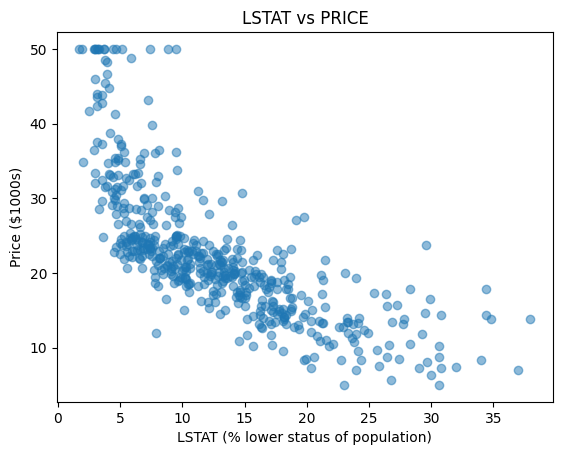

In [5]:
X = df['LSTAT'].values.reshape(-1, 1)
y = y_boston

plt.plot(X, y, "o", alpha=0.5)
plt.xlabel("LSTAT (% lower status of population)")
plt.ylabel("Price ($1000s)")
plt.title("LSTAT vs PRICE")
plt.savefig("Boston_Taski.png", dpi=300, bbox_inches='tight')
plt.show()

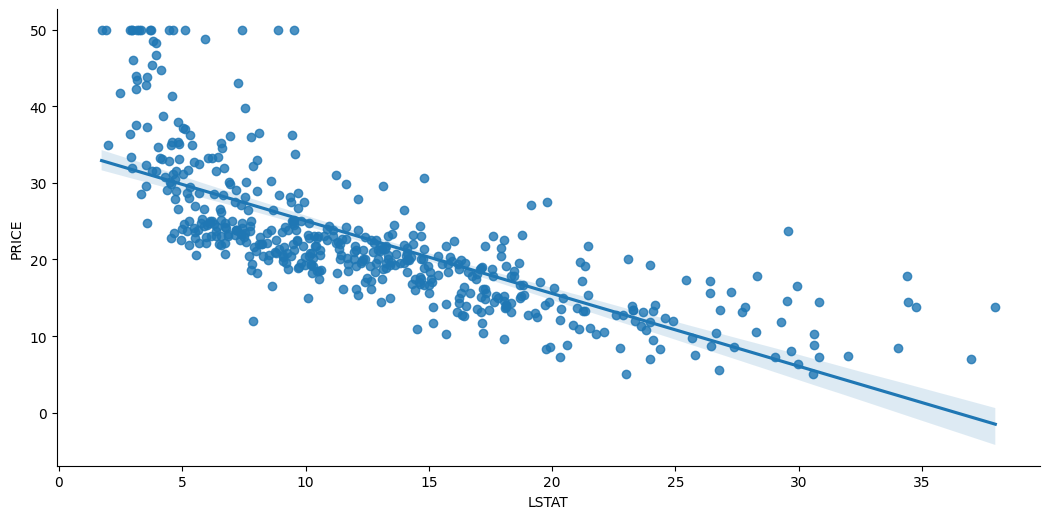

In [6]:
sns.lmplot(x="LSTAT", y="PRICE", data=df, height =5.3, aspect=2)

#Save the plot
plt.savefig("lmplotBostonLSTAT.png", dpi=300, bbox_inches='tight')
plt.show()

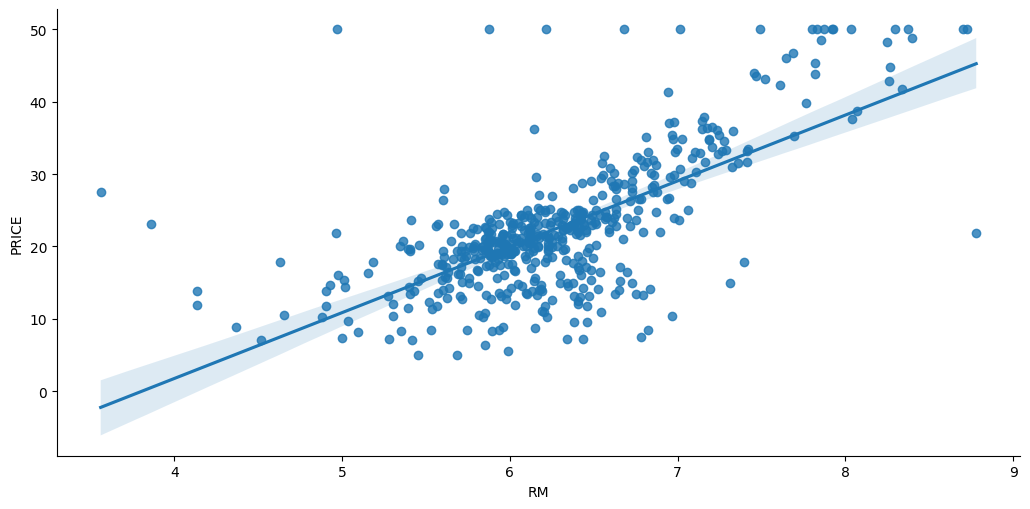

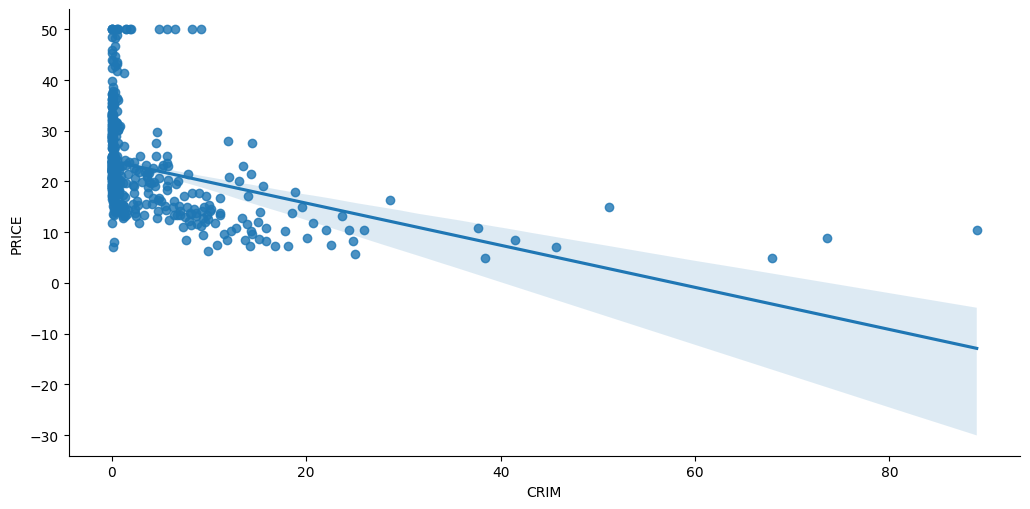

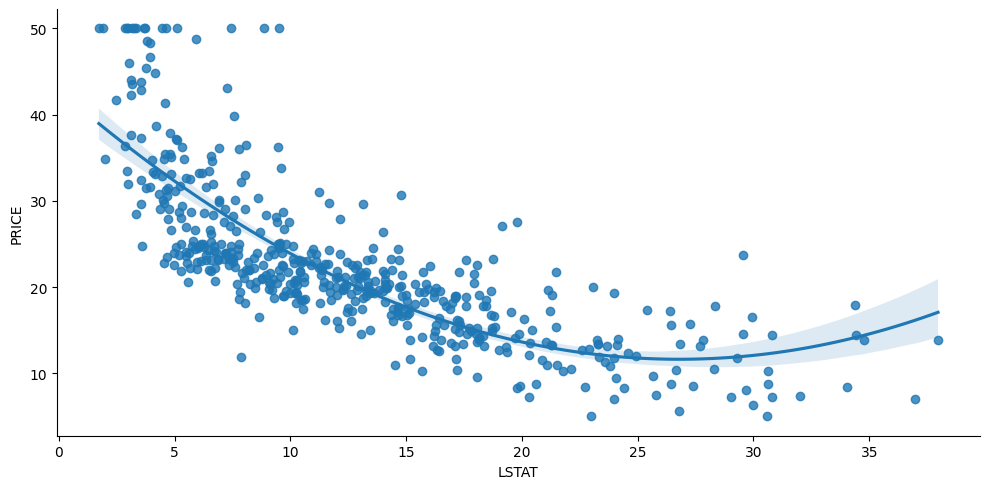

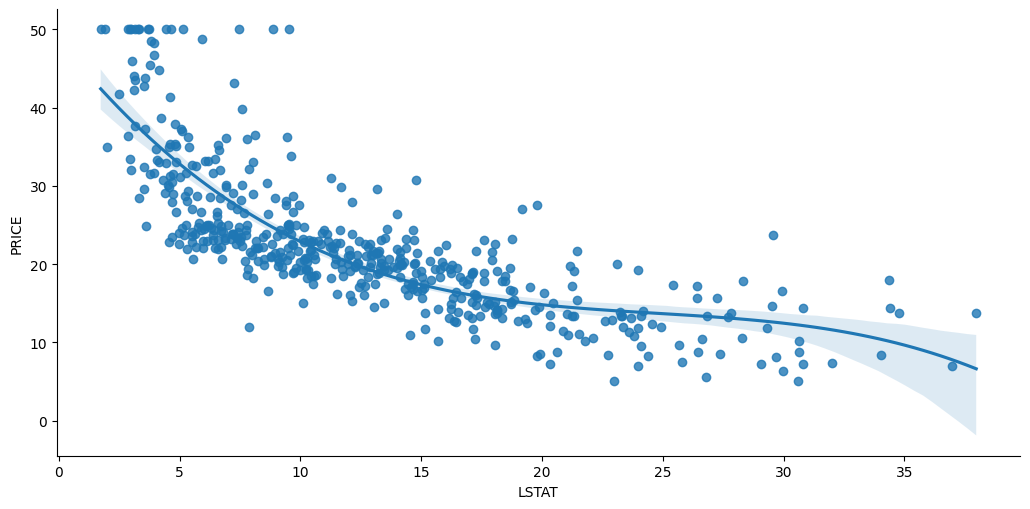

In [7]:
#Visualization of the relations between price and RM
sns.lmplot(x = "RM", y = "PRICE", data=df, height = 5.2, aspect = 2)
plt.show()
#VIsualization of the relations between price and CRIM
sns.lmplot(x = "CRIM", y = "PRICE", data=df, height = 5.2, aspect = 2)
plt.show()

sns.lmplot(x = "LSTAT", y = "PRICE", data=df, order = 2, aspect = 2)
plt.savefig("lmplotBostonLSTAT_order2.png", dpi=300, bbox_inches = 'tight')
plt.show()

sns.lmplot(x = "LSTAT", y = "PRICE", data=df, order = 3, height = 5.2, aspect = 2)
plt.savefig("lmplotBostonLSTATorder3.png", dpi=300, bbox_inches = 'tight')
plt.show()

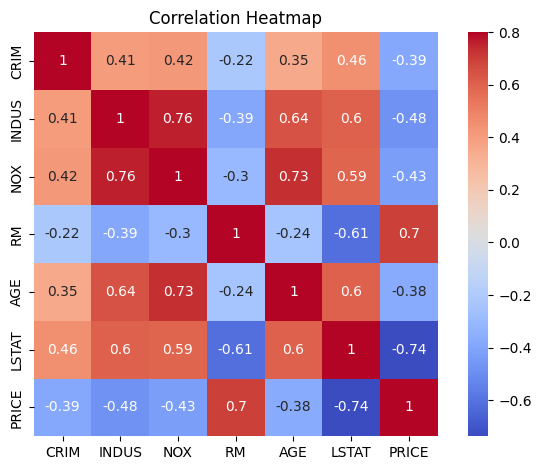

In [8]:
# Select subset of feature 
features2 = ['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'LSTAT', 'PRICE']
df_boston2 = df[features2] #USe your manually loaded DataFrame

#Compute correlation matrix
corrmat = df_boston2.corr()

# plot heatmap
sns.heatmap(corrmat, vmax=0.8, square=True, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()

#Save the figure
plt.savefig("corrplot.png", dpi=300, bbox_inches='tight')
plt.show()

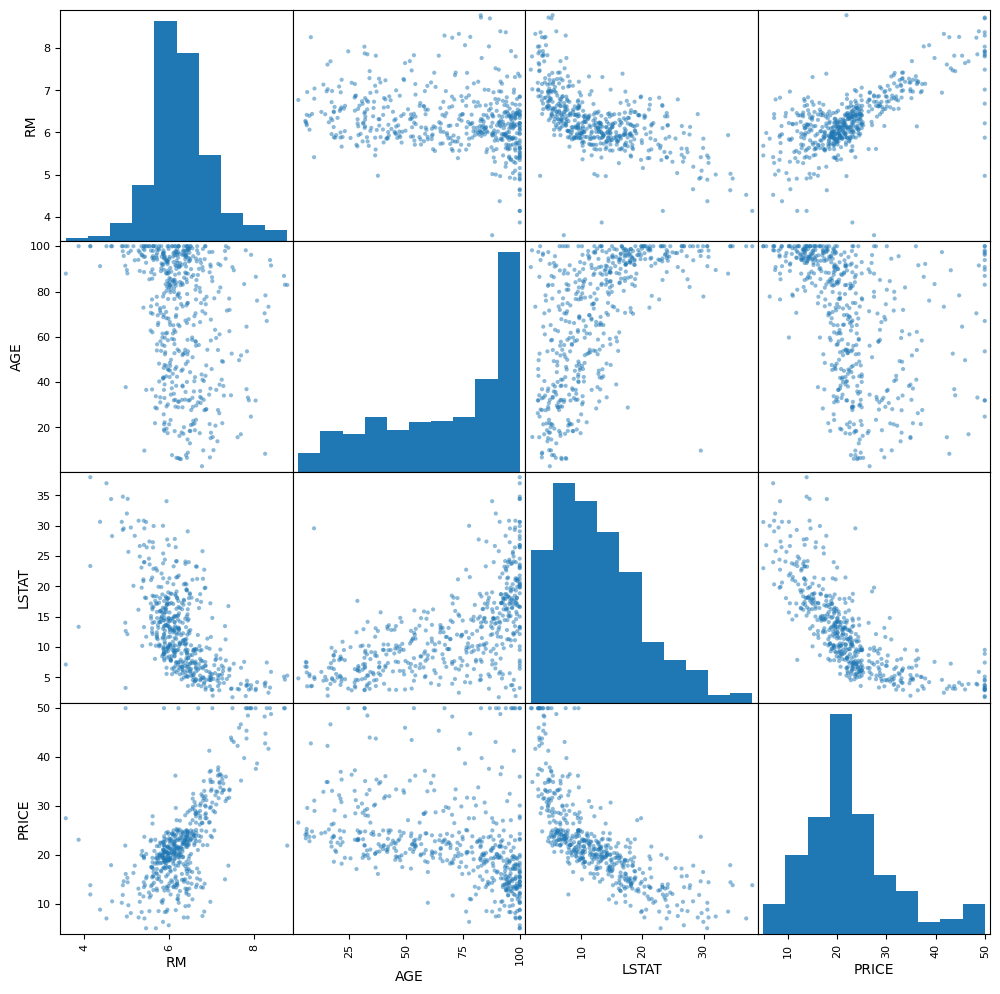

In [9]:
features3 = ['RM', 'AGE', 'LSTAT', 'PRICE']
df_boston3 = df[features3]
pd.plotting.scatter_matrix(df_boston3, figsize=(12.0, 12.0))
plt.savefig("scatterplotBoston.png", dpi=300, bbox_inches = 'tight')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
seed = 1 # Make predictions deterministic

# REuse already defined X_boston and y_boston from you processed dataset
X_train, X_test, y_train, y_test = train_test_split(X_boston, y_boston, test_size=0.5, random_state=seed)

print('Train and test sizes of X: {} {}'.format(X_train.shape, X_test.shape))
print('Train and test sized of y: {} {}'.format(y_train.shape, y_test.shape))

Train and test sizes of X: (253, 13) (253, 13)
Train and test sized of y: (253,) (253,)
